# Credit Card Fraud Detection Using Clustering

## Objective
To use K-Means clustering, an unsupervised learning technique, to detect anomalous (potentially fraudulent) credit card transactions and evaluate the detected anomalies against the actual fraud labels.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
# Analyze the Distribution of class
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [9]:
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


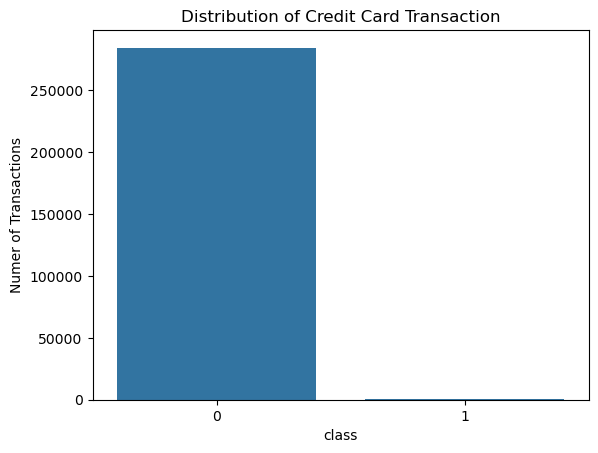

In [10]:
sns.countplot(x="Class", data=df)

plt.title("Distribution of Credit Card Transaction")
plt.xlabel("class")
plt.ylabel("Numer of Transactions")
plt.show()

## Why is this an Anomaly Detection Problem?

Credit card fraud detection is an anomaly detection problem because fraudulent transactions are very rare compared to normal transactions.

Most transactions are normal, while only a very small number of transactions are fraudulent. Therefore, fraud transactions can be considered as unusual or anomalous observations.

Since clustering is an unsupervised learning technique, the model will learn patterns from the transaction features without using the "Class" column. Later, the detected anomalies can be compared with the actual "Class" values to evaluate the model.

## insight

The dataset is highly imbalanced, with normal transactions making up the vast majority of the data and fraudulent transactions representing only a very small percentage.
This makes the problem an anomaly detection problem, because fraudulent transactions are rare and can be treated as unusual patterns compared with normal transactions.

## Data preprocessing Feature selection

In [11]:
from sklearn.preprocessing import StandardScaler

X = df.drop("Class", axis=1)
y = df["Class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


print("Scaled shape:",X_scaled.shape)

Scaled shape: (284807, 30)


## insight
Feature scaling was performed using StandardScaler so that all selected features have a similar scale. This is important because K-Means uses distance to assign observations to clusters. Without scaling, features with larger numerical values could have a greater influence on the clustering results.

In [12]:
# Select relevant features

X = df.drop(["Time", "Class"], axis=1)

# Scale the selected features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Selected features:")
print(X.columns)

print("\nScaled data shape:", X_scaled.shape)

Selected features:
Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')

Scaled data shape: (284807, 29)


## insight
The Time and Class columns are excluded from the clustering features. The Class column contains the actual fraud labels, so it must not be used for unsupervised learning. The selected features are used to identify transaction patterns and anomalies.

## K-Means Clustering - Elbow Method

In [13]:
from sklearn.cluster import KMeans

inertia = []
K_range =range(2,11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

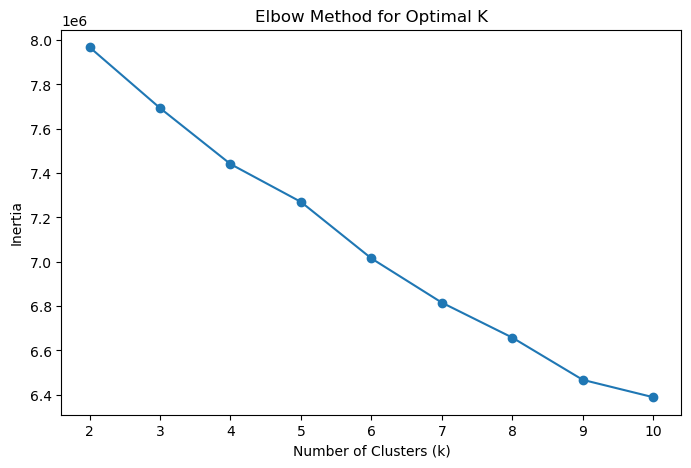

In [14]:
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

## insight
The Elbow Method was used to determine a suitable number of clusters. The inertia decreases as the number of clusters increases. Based on the elbow point observed in the plot, K = 4 was selected for the K-Means clustering model.

## Trian the K-Means Model

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

clusters = kmeans.labels_

print("K-Means clustering completed.")
print("Number of clusters:",len(set(clusters)))

K-Means clustering completed.
Number of clusters: 4


In [16]:
print(pd.Series(clusters).value_counts())

1    135253
0    124603
2     20205
3      4746
Name: count, dtype: int64


## insight
K-Means clustering was successfully applied with four clusters. Each transaction was assigned to one of the four clusters based on its similarity to the cluster centroids. These clusters represent different transaction patterns and are not directly considered as normal or fraudulent.

## Calculate Distance from cluster centroid

In [35]:
# Get the centroid of the assigned cluster for each transaction
centroids = kmeans.cluster_centers_[clusters]


distances = np.linalg.norm(X_scaled - centroids, axis=1)

print("Distance calculation completed.")
print(distances[:10])
df.head()

Distance calculation completed.
[3.10190367 2.43698054 6.44377762 4.53308192 3.3368965  2.32150418
 2.84997964 7.27887987 4.20567383 2.82581152]


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Insight
The Euclidean distance between each transaction and its assigned cluster centroid was calculated. Transactions with larger distances are more different from the normal patterns within their clusters and are therefore more likely to be anomalous.

## Identify top1% anomalies

In [18]:
# Find the 99th percentile of distances
threshold = np.percentile(distances, 99)

print("Anomaly threshold:", threshold)

Anomaly threshold: 14.290710655520924


In [19]:
# Label top 1% as anomalies
anomaly_labels = (distances >= threshold).astype(int)

print(pd.Series(anomaly_labels).value_counts())

0    281958
1      2849
Name: count, dtype: int64


## Insight
The 99th percentile of the distance was used as the anomaly threshold. Transactions whose distance was greater than or equal to this threshold were classified as anomalies. Therefore, approximately 1% of the transactions were identified as potential anomalies.

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, anomaly_labels)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[281773   2542]
 [   185    307]]


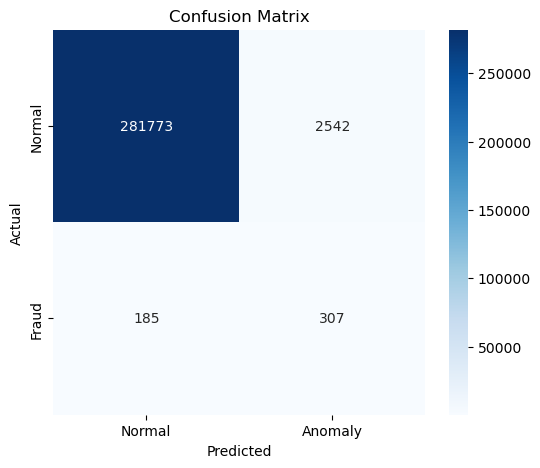

In [32]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Insight
The 99th percentile of the distance was used as the anomaly threshold. Transactions whose distance was greater than or equal to this threshold were classified as anomalies. Therefore, approximately 1% of the transactions were identified as potential anomalies.

In [21]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y, anomaly_labels)
recall = recall_score(y, anomaly_labels)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.10775710775710776
Recall: 0.6239837398373984


##
Precision: Among the transactions identified as anomalies, only about 10.81% were actually fraudulent. This means the model produced a relatively high number of false positives.
Recall: The model detected about 62.60% of the actual fraudulent transactions. This means it successfully identified more than half of the fraud cases.
Overall, the clustering-based anomaly detection method was able to detect a significant portion of fraudulent transactions, but its precision was low because many normal transactions were also classified as anomalies.

In [22]:
from sklearn.decomposition import PCA

# Reduce features to 2 dimensions
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

print("PCA completed.")
print("PCA shape:", X_pca.shape)

PCA completed.
PCA shape: (284807, 2)


## Insight
PCA was used to reduce the 29-dimensional feature space to two dimensions. This makes it possible to visualize the clustering results and the detected anomalies in a two-dimensional plot while preserving as much variation in the data as possible.

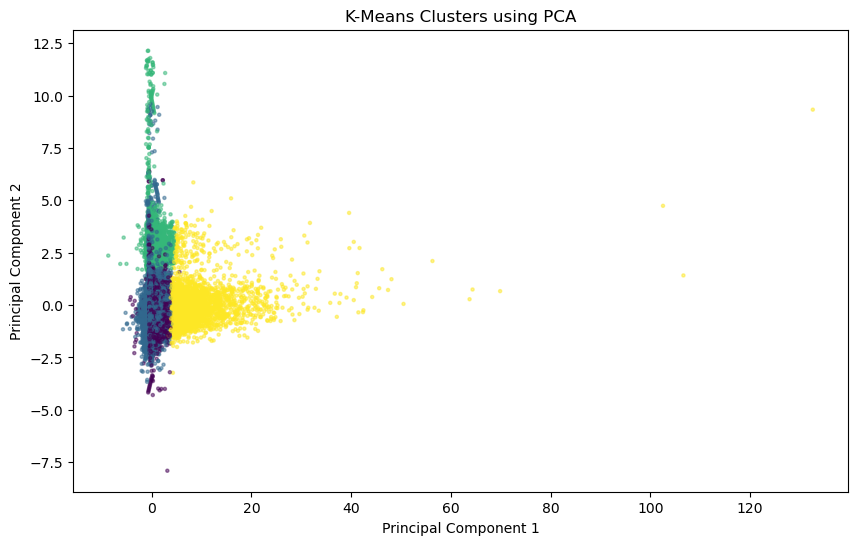

In [23]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    s=5,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters using PCA")
plt.show()

## Insight
The PCA plot shows the four clusters formed by the K-Means algorithm. Each point represents a credit card transaction, and points with similar patterns are grouped into the same cluster.

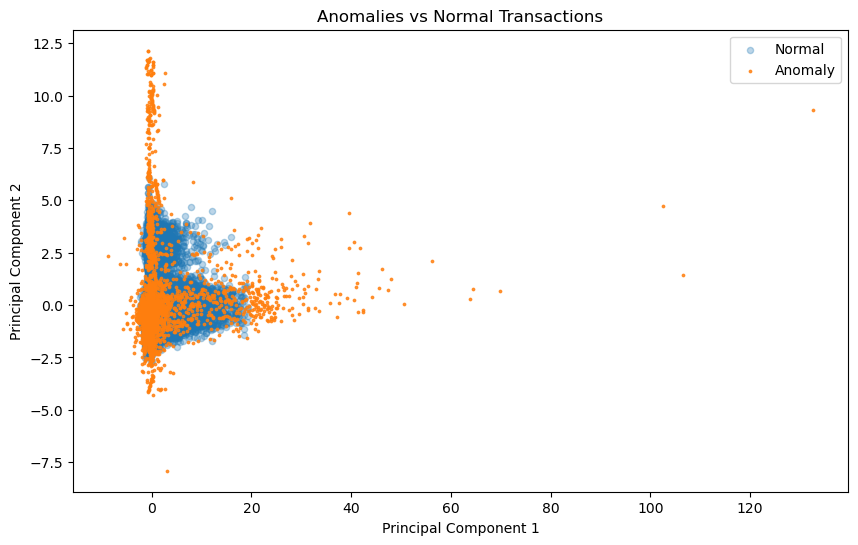

In [31]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[anomaly_labels == 0, 0],
    X_pca[anomaly_labels == 0, 1],
    s=20,
    alpha=0.3,
    label="Normal"
)

plt.scatter(
    X_pca[anomaly_labels == 1, 0],
    X_pca[anomaly_labels == 1, 1],
    s=3,
    alpha=0.8,
    label="Anomaly"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Anomalies vs Normal Transactions")
plt.legend()
plt.show()

## Insight
The PCA visualization shows the normal transactions and the transactions identified as anomalies. The anomaly detection method labels the top 1% of transactions with the largest distance from their cluster centroids as anomalies.

## Conclusion
K-Means clustering was successfully used as an unsupervised anomaly detection technique for credit card transactions. The model identified potentially unusual transactions based on their distance from cluster centroids. The detected anomalies were then compared with actual fraud cases using Precision, Recall, and a Confusion Matrix. Although the method can detect a portion of fraudulent transactions, some normal transactions are also identified as anomalies. Therefore, clustering can be useful as an initial fraud detection approach, but additional supervised or advanced anomaly detection techniques may improve fraud detection performance.